<a href="https://colab.research.google.com/github/Siddanth-tech/Eda-25BAI0031/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from scipy.cluster.hierarchy import dendrogram, linkage
from pandas.plotting import parallel_coordinates, andrews_curves

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [3]:
np.random.seed(42)
n_samples = 200

categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Beauty']
states = ['California', 'Texas', 'New York', 'Florida', 'Illinois']
state_codes = {'California': 'CA', 'Texas': 'TX', 'New York': 'NY', 'Florida': 'FL', 'Illinois': 'IL'}


In [4]:
df = pd.DataFrame({
    'CustomerID': range(1, n_samples + 1),
    'Age': np.random.randint(18, 65, size=n_samples),
    'AnnualIncome': np.random.randint(30, 150, size=n_samples),  # in $1,000s
    'SpendingScore': np.random.randint(1, 100, size=n_samples),
    'Category': np.random.choice(categories, size=n_samples, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
    'PurchaseAmount': np.random.exponential(scale=120, size=n_samples).round(2) + 10,
    'State': np.random.choice(states, size=n_samples),
    'FeedbackText': np.random.choice([
        "great fast shipping excellent quality product",
        "terrible customer service delayed delivery broken item",
        "good product reasonable price highly recommend",
        "average quality slow shipping customer support helpful",
        "fantastic experience top notch product fast delivery"
    ], size=n_samples)
})

In [5]:
df['StateCode'] = df['State'].map(state_codes)

print("Dataset Overview:")
print(df.head())

Dataset Overview:
   CustomerID  Age  AnnualIncome  SpendingScore        Category  \
0           1   56            68             87          Beauty   
1           2   46            31             33        Clothing   
2           3   32            32             67        Clothing   
3           4   60           142             18  Home & Kitchen   
4           5   25           130             25  Home & Kitchen   

   PurchaseAmount     State  \
0           60.15     Texas   
1          102.47  New York   
2           83.97   Florida   
3          115.47     Texas   
4           71.36  Illinois   

                                        FeedbackText StateCode  
0  fantastic experience top notch product fast de...        TX  
1      great fast shipping excellent quality product        NY  
2  fantastic experience top notch product fast de...        FL  
3  terrible customer service delayed delivery bro...        TX  
4  fantastic experience top notch product fast de...        IL  


pie chart

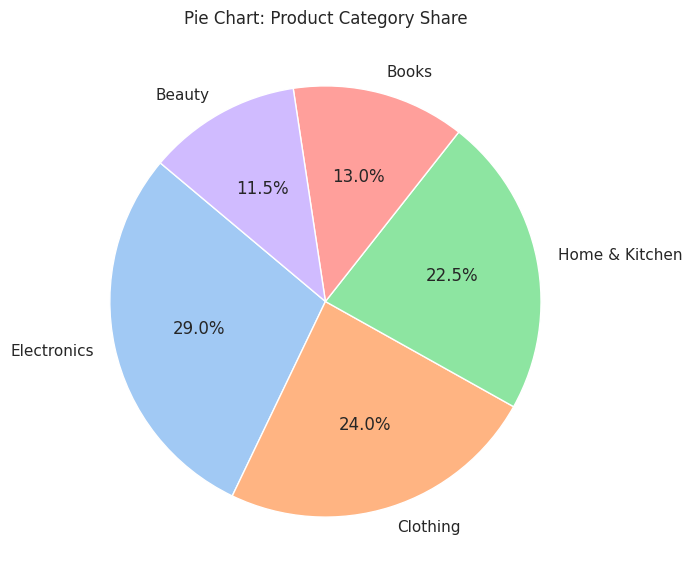

In [6]:
category_counts = df['Category'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Pie Chart: Product Category Share")
plt.show()

barchart

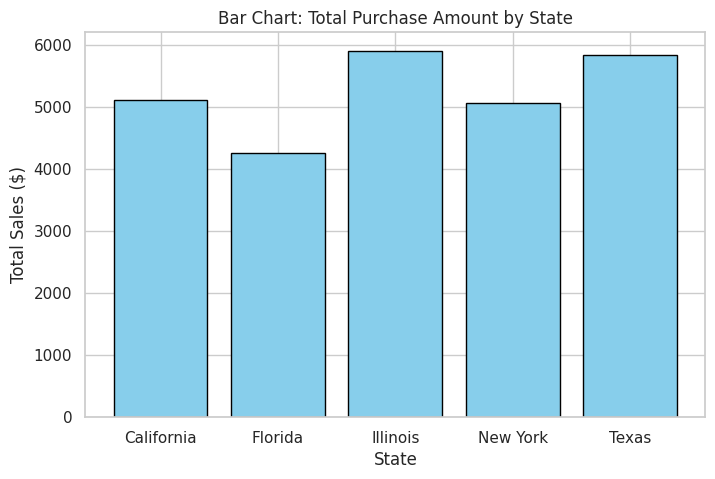

In [7]:
state_sales = df.groupby('State')['PurchaseAmount'].sum().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(state_sales['State'], state_sales['PurchaseAmount'], color='skyblue', edgecolor='black')
plt.title("Bar Chart: Total Purchase Amount by State")
plt.xlabel("State")
plt.ylabel("Total Sales ($)")
plt.show()

histogram

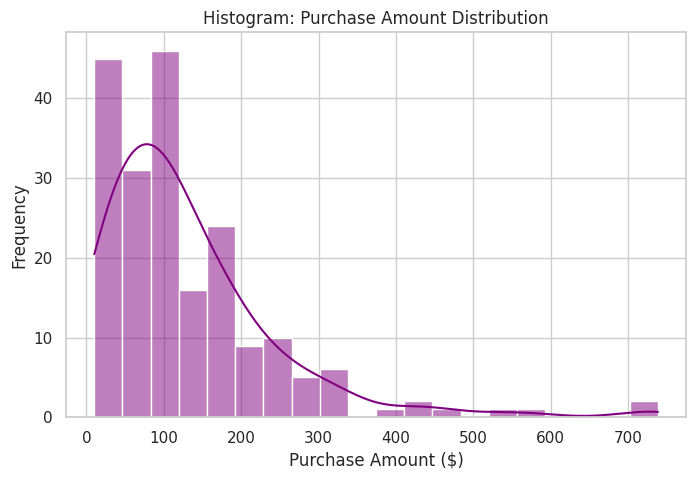

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['PurchaseAmount'], kde=True, color='purple', bins=20)
plt.title("Histogram: Purchase Amount Distribution")
plt.xlabel("Purchase Amount ($)")
plt.ylabel("Frequency")
plt.show()

heat map

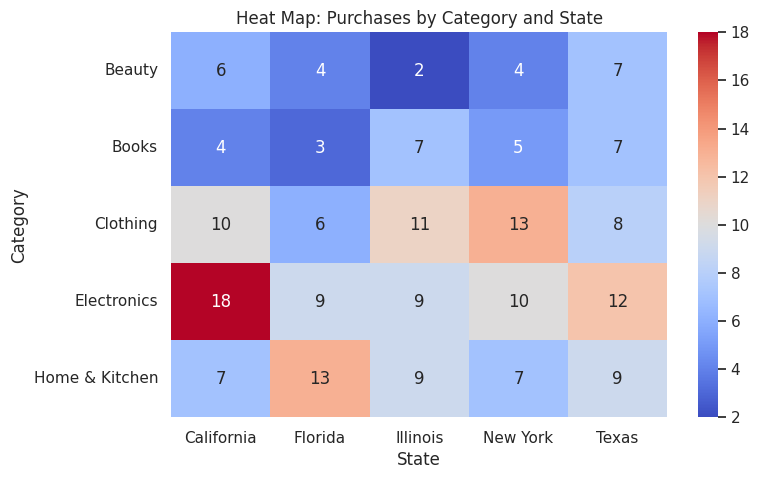

In [9]:
cstab = pd.crosstab(df['Category'], df['State'])
plt.figure(figsize=(8, 5))
sns.heatmap(cstab, annot=True, fmt='d', cmap='coolwarm')
plt.title("Heat Map: Purchases by Category and State")
plt.xlabel("State")
plt.ylabel("Category")
plt.show()

cloropleth map

In [10]:
state_totals = df.groupby('StateCode')['PurchaseAmount'].sum().reset_index()
fig = px.choropleth(
    state_totals,
    locations='StateCode',
    locationmode="USA-states",
    color='PurchaseAmount',
    scope="usa",
    color_continuous_scale="Viridis",
    title="Choropleth Map: Total Revenue by State"
)
fig.show()

dendrogram

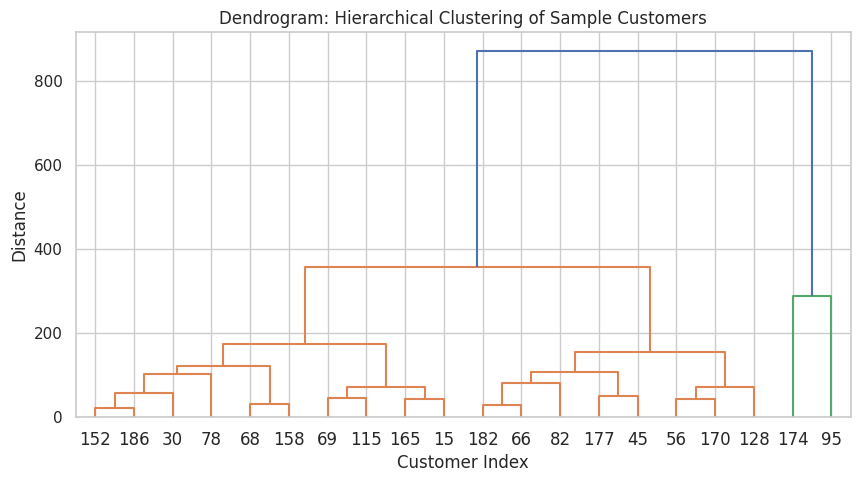

In [14]:
numeric_df = df[['Age', 'AnnualIncome', 'SpendingScore', 'PurchaseAmount']].sample(20, random_state=42)
linked = linkage(numeric_df, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, labels=numeric_df.index.tolist(), distance_sort='descending', show_leaf_counts=True)
plt.title("Dendrogram: Hierarchical Clustering of Sample Customers")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()

scatter plot

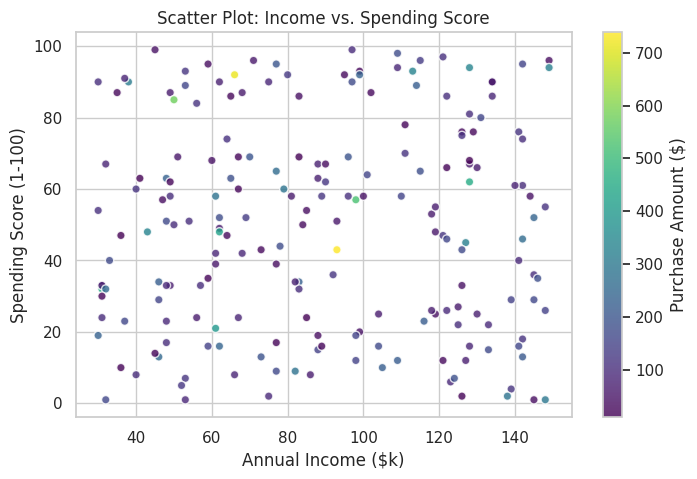

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['PurchaseAmount'], cmap='viridis', alpha=0.8, edgecolors='w')
plt.colorbar(label='Purchase Amount ($)')
plt.title("Scatter Plot: Income vs. Spending Score")
plt.xlabel("Annual Income ($k)")
plt.ylabel("Spending Score (1-100)")
plt.show()

correlation heat map

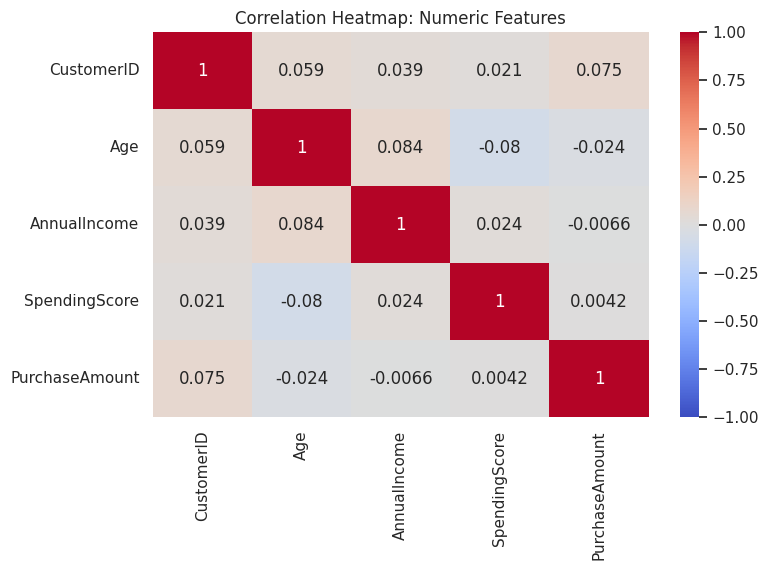

In [17]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Numeric Features")
plt.show()

pair plot

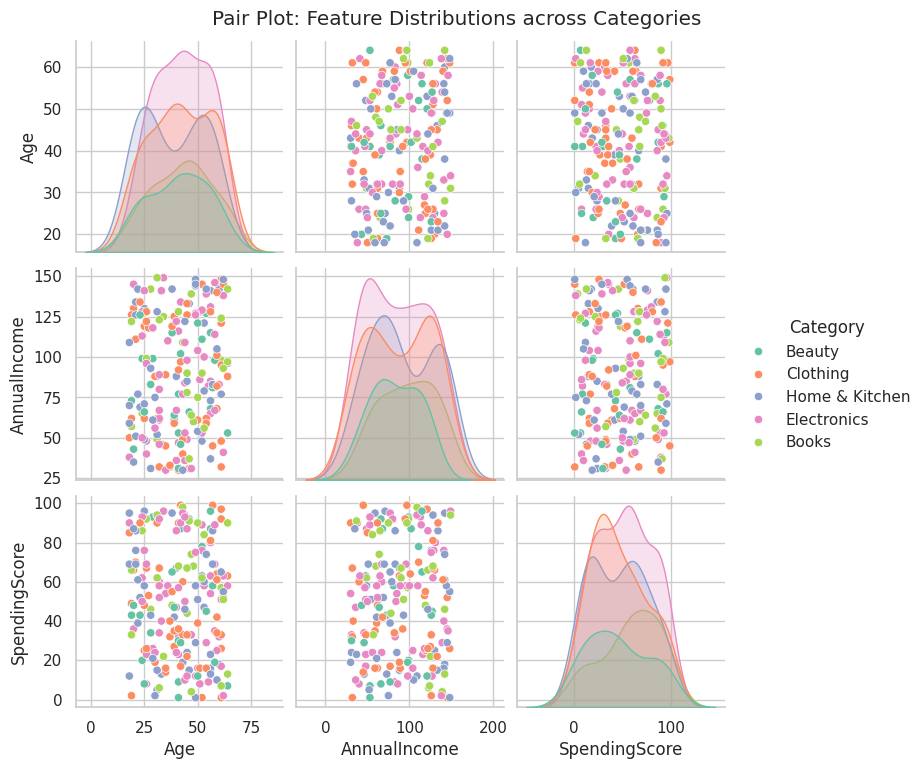

In [16]:
sns.pairplot(df[['Age', 'AnnualIncome', 'SpendingScore', 'Category']], hue='Category', palette='Set2')
plt.suptitle("Pair Plot: Feature Distributions across Categories", y=1.02)
plt.show()

parrelel coordinate plot

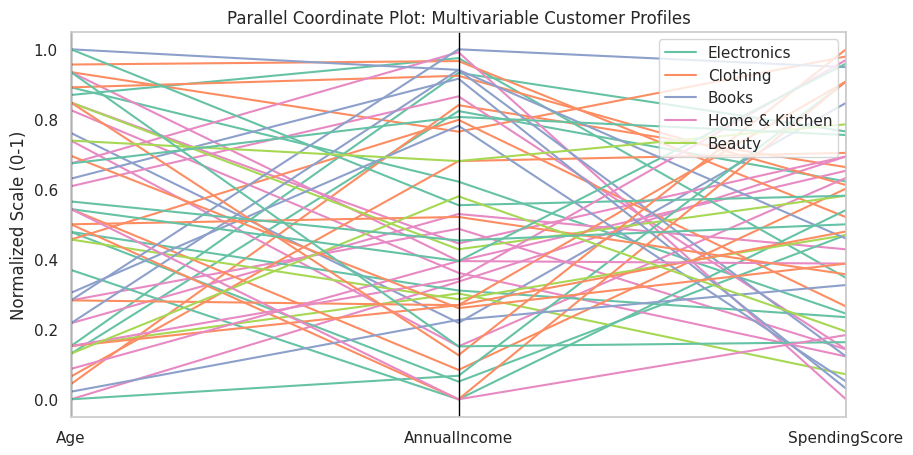

In [18]:
normalized_df = df[['Age', 'AnnualIncome', 'SpendingScore', 'Category']].copy()
for col in ['Age', 'AnnualIncome', 'SpendingScore']:
    normalized_df[col] = (normalized_df[col] - normalized_df[col].min()) / (normalized_df[col].max() - normalized_df[col].min())

plt.figure(figsize=(10, 5))
parallel_coordinates(normalized_df.sample(50, random_state=42), class_column='Category', color=sns.color_palette('Set2', 5))
plt.title("Parallel Coordinate Plot: Multivariable Customer Profiles")
plt.ylabel("Normalized Scale (0-1)")
plt.show()

andrews curves

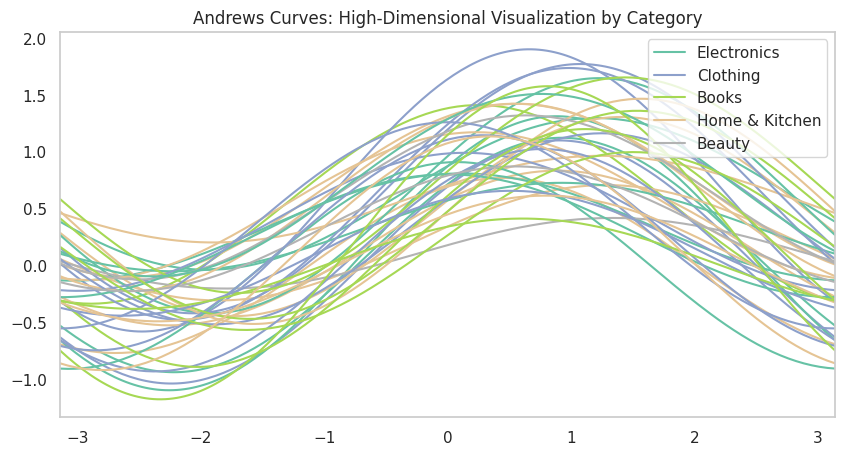

In [19]:
plt.figure(figsize=(10, 5))
andrews_curves(normalized_df.sample(40, random_state=42), class_column='Category', colormap='Set2')
plt.title("Andrews Curves: High-Dimensional Visualization by Category")
plt.show()